
Import Modules

In [32]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import face_recognition
from scipy.spatial import distance
import pygame

import warnings
warnings.filterwarnings('ignore')

In [33]:
pip install "setuptools<81"


Note: you may need to restart the kernel to use updated packages.


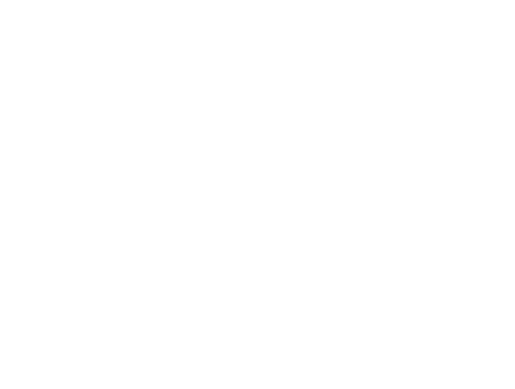

In [34]:
image_path = 'test1.jpg'
image = Image.open(image_path)
plt.axis('off')
# plt.imshow(image)
plt.show()


In [35]:
def highlight_facial_points(image_path):
    # load the image
    image_bgr = cv2.imread(image_path)
    # convert from bgr to rgb
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # detect faces in the image
    face_locations=face_recognition.face_locations(image_rgb, model='cnn')

    for face_location in face_locations:
        # get facial landmarks
        landmarks = face_recognition.face_landmarks(image_rgb, [face_location])[0]

        # Iterate over the facial landmarks and draw them on the image
        for landmark_type, landmark_points in landmarks.items():
            for (x, y) in landmark_points:
                cv2.circle(image_rgb, (x, y), 1, (0, 255, 0), -1)

    # plot the image
    plt.figure(figsize=(6, 6))
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.show()

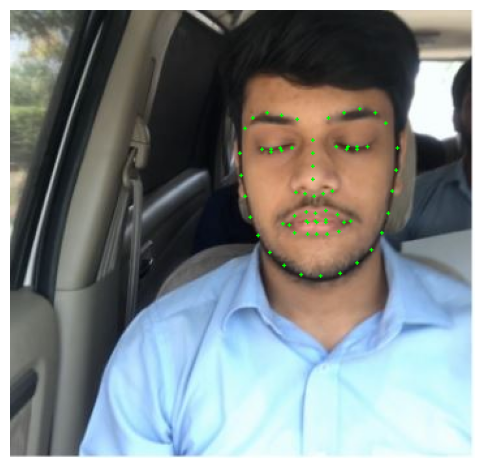

In [36]:
highlight_facial_points(image_path)

In [38]:
# calculate eye aspect ratio
def eye_aspect_ratio(eye):
    A = distance.euclidean(eye[1], eye[5])
    B = distance.euclidean(eye[2], eye[4])
    C = distance.euclidean(eye[0], eye[3])
    ear = (A+B) / (2.0 * C)
    return ear

# calculate mount aspect ratio
def mouth_aspect_ratio(mouth):
    A = distance.euclidean(mouth[2], mouth[10])
    B = distance.euclidean(mouth[4], mouth[8])
    C = distance.euclidean(mouth[0], mouth[6])
    mar = (A+B) / (2.0 * C)
    return mar

In [39]:
def process_image(frame):
    # define thresholds
    EYE_AR_THRESH = 0.25
    MOUTH_AR_THRESH = 0.6

    if frame is None:
        raise ValueError('Image is not found or unable to open')

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # find all face locations
    face_locations = face_recognition.face_locations(rgb_frame)

    # initiate flags
    eye_flag = mouth_flag = False

    for face_location in face_locations:
        # extract facial landmarks
        landmarks = face_recognition.face_landmarks(rgb_frame, [face_location])[0]
        # extract eye and mouth coordinates
        left_eye = np.array(landmarks['left_eye'])
        right_eye = np.array(landmarks['right_eye'])
        mouth = np.array(landmarks['bottom_lip'])

        # calculate ear and mar
        left_ear = eye_aspect_ratio(left_eye)
        right_ear = eye_aspect_ratio(right_eye)
        ear = (left_ear+right_ear) / 2.0
        mar = mouth_aspect_ratio(mouth)

        # check if eyes are closed
        if ear < EYE_AR_THRESH:
            eye_flag = True

        # check if yawning
        if mar > MOUTH_AR_THRESH:
            mouth_flag = True

    return eye_flag, mouth_flag

In [40]:
img = cv2.imread(image_path)
process_image(img)

(True, False)

In [41]:
import cv2
import pygame
import time

# Initialize pygame mixer once
pygame.mixer.init()

# last alarm time (global variable for cooldown)
last_alarm_time = 0
cooldown_seconds = 5   # alarm plays at most once every 5 seconds
MAX_SCORE = 20         # 🔹 maximum score cap

def play_alarm():
    global last_alarm_time
    current_time = time.time()
    if current_time - last_alarm_time >= cooldown_seconds:
        if not pygame.mixer.music.get_busy():  # play only if not already playing
            pygame.mixer.music.load("alarm.mp3")  # make sure alarm.mp3 is in same folder
            pygame.mixer.music.play(-1)  # 🔄 loop until stopped
        last_alarm_time = current_time

def stop_alarm():
    if pygame.mixer.music.get_busy():
        pygame.mixer.music.stop()

video_cap = cv2.VideoCapture(0)  # webcam
count = 0
eye_score = 0.0
mouth_score = 0.0

# Parameters (less strict on eyes)
EYE_INC = 0.6        # 👁️ lower increment → eyes less influential
MOUTH_INC = 0.8      # yawning still important
DECAY = 0.5          # gradual decay factor
THRESHOLD = 3        # when to start alarm

while True:
    success, image = video_cap.read()
    if not success:
        break

    image = cv2.resize(image, (800, 500))
    count += 1

    # process every nth frame
    n = 3
    if count % n == 0:
        eye_flag, mouth_flag = process_image(image)

        # Update eye score
        if eye_flag:
            eye_score += EYE_INC
        else:
            eye_score = max(0, eye_score - DECAY)

        # Update mouth score
        if mouth_flag:
            mouth_score += MOUTH_INC
        else:
            mouth_score = max(0, mouth_score - DECAY)

    # Total weighted score (👁️ eyes weight reduced)
    score = (eye_score * 1.2) + mouth_score   # was *2, now *1.2

    # 🔹 enforce score limits
    if score > MAX_SCORE:
        score = MAX_SCORE
        stop_alarm()  # auto-stop if maxed out

    # Draw scores on screen
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(image, f"Score: {score:.1f}", (10, image.shape[0] - 10),
                font, 0.8, (0, 255, 0), 2, cv2.LINE_AA)
    # cv2.putText(image, f"Eyes:{eye_score:.1f}  Mouth:{mouth_score:.1f}", (10, 30),
                # font, 0.7, (255, 255, 0), 2, cv2.LINE_AA)

    # Check thresholds
    if THRESHOLD <= score < MAX_SCORE:
        cv2.putText(image, "Drowsy Detected", (image.shape[1] - 250, 60),
                    font, 1, (0, 0, 255), 2, cv2.LINE_AA)
        play_alarm()
    elif score < THRESHOLD:
        stop_alarm()

    # Show video
    cv2.imshow('drowsiness detection', image)

    # 🔹 Keypress check (resets score)
    key = cv2.waitKey(1) & 0xFF
    if key != 255:   # any key pressed
        eye_score = 0
        mouth_score = 0
        score = 0
        stop_alarm()
        print("✅ Score reset by user")

    # Exit on ESC
    if key == 27:
        break

video_cap.release()
cv2.destroyAllWindows()


✅ Score reset by user


# 